# Plot Etv2 expression in early cell types

In [1]:
here::i_am("rna_atac/clustering/02_clustering.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [60]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [62]:
# Load meta
meta = fread(args$metadata) %>% 
    .[day == 'D3.5'] %>%
    .[celltype_v2 %in% c('Primitive_Streak', 'Early_Mes_EOi', 'Early_Mes_EOd', 'HE_Precursor')]  # Only WT cells for celltype marker search

In [63]:
unique(fread(args$metadata)$celltype_v2)

[1] "Primitive_Streak"    "Early_Mes_EOi"       "Early_Mes_EOd"      
 [4] "PGC"                 "Posterior_Mes"       "HE_Precursor"       
 [7] "HE"                  "Mesenchyme"          "Allantois_Precursor"
[10] "Blood_Progenitor"    "Endothelium"         "Allantois"

In [64]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [67]:
opts$celltype_v2_figure

PGC             Allantois   Allantois_Precursor 
                "PGC"           "Allantois" "Allantois Precursor" 
           Mesenchyme         Posterior_Mes         Early_Mes_EOi 
         "Mesenchyme"       "Posterior Mes"        "Early-Mes #1" 
     Primitive_Streak         Early_Mes_EOd          HE_Precursor 
   "Primitive Streak"        "Early-Mes #2"        "HE Precursor" 
                   HE           Endothelium      Blood_Progenitor 
                 "HE"         "Endothelium"    "Blood Progenitor"

In [74]:
meta2 = meta %>%
    .[, Etv2 := as.vector(logcounts(rna.sce['Etv2',]))] %>%
    .[, celltype_figure := opts$celltype_v2_figure[match(celltype_v2, names(opts$celltype_v2_figure))]] %>%
    .[, celltype_figure := factor(celltype_figure, levels = c("Primitive Streak", 'Early-Mes #1', 'Early-Mes #2', 'HE Precursor'))] %>%
    .[!(celltype_figure == 'Early-Mes #2' & genotype == 'KO') & !(celltype_figure == 'HE Precursor' & genotype == 'KO')]

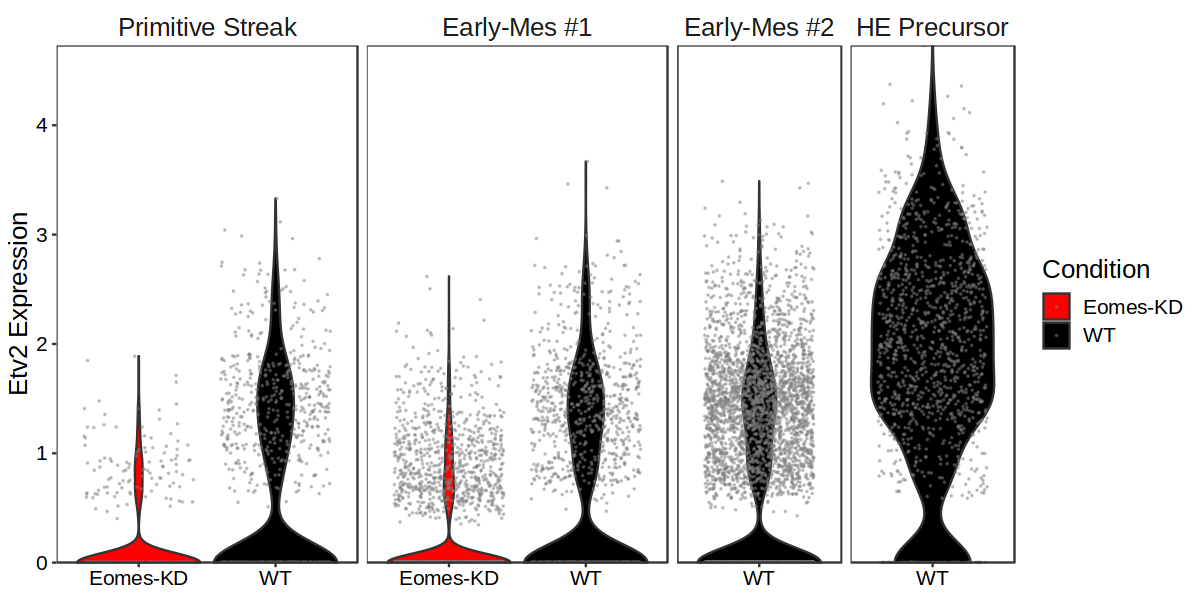

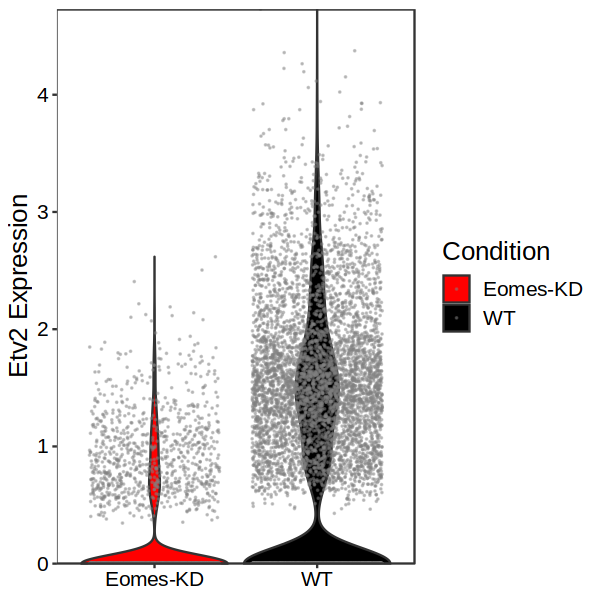

In [81]:
options(repr.plot.width = 10, repr.plot.height = 5)
ggplot(meta2, aes(gsub('KO', 'Eomes-KD', genotype), Etv2, fill = gsub('KO', 'Eomes-KD', genotype))) +
    geom_violin(scale = 'width') + 
    geom_point(size = 0, alpha = 0.4, position = position_jitter(width = 0.4), color = 'grey50') + 
    #geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    scale_y_continuous(expand = c(0,0,0,0), name = 'Etv2 Expression') +
    scale_fill_manual(values = c('Eomes-KD' = 'red', 'WT' = 'black'), name = 'Condition') +
    facet_grid(~celltype_figure, scales = 'free_x', space = 'free') + 
    theme_bw() + 
    theme(panel.grid = element_blank(),
          strip.background = element_blank(),
          axis.text = element_text(color = 'black', size = 12),
          axis.title = element_text(size = 15),
          strip.text = element_text(size = 15),
          legend.text = element_text(size = 12),
          legend.title = element_text(size = 15),
          axis.title.x = element_blank()
         )

options(repr.plot.width = 5, repr.plot.height = 5)
ggplot(meta2, aes(gsub('KO', 'Eomes-KD', genotype), Etv2, fill = gsub('KO', 'Eomes-KD', genotype))) +
    geom_violin(scale = 'width') + 
    geom_point(size = 0, alpha = 0.4, position = position_jitter(width = 0.4), color = 'grey50') + 
    #geom_boxplot(fill = 'white', width = 0.2, outlier.shape = NA) + 
    scale_y_continuous(expand = c(0,0,0,0), name = 'Etv2 Expression') +
    scale_fill_manual(values = c('Eomes-KD' = 'red', 'WT' = 'black'), name = 'Condition') +
    theme_bw() + 
    theme(panel.grid = element_blank(),
          strip.background = element_blank(),
          axis.text = element_text(color = 'black', size = 12),
          axis.title = element_text(size = 15),
          strip.text = element_text(size = 15),
          legend.text = element_text(size = 12),
          legend.title = element_text(size = 15),
          axis.title.x = element_blank()
         )